**Upload Dataset**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings

warnings.filterwarnings("ignore")

# Define URLs for each client's dataset
client_1_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/Modified_Cardiovascular_Disease_Dataset.csv"
client_2_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/heart.csv"
client_3_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/Cardiovascular_Disease_Dataset.csv"

# Load the datasets
client_1_df = pd.read_csv(client_1_url)
client_2_df = pd.read_csv(client_2_url)
client_3_df = pd.read_csv(client_3_url)

# Drop "Unnamed" column from client_1_df
client_1_df = client_1_df.loc[:, ~client_1_df.columns.str.contains('^Unnamed')]

# Drop "patientid" column from client_3_df
client_3_df = client_3_df.drop(columns=["patientid"], errors='ignore')

# Target variable for each client
client_1_target = 'target'
client_2_target = 'HeartDisease'
client_3_target = 'target'

# Separate numeric and categorical columns for Client 2
client_2_numeric_cols = client_2_df.select_dtypes(include=[np.number]).columns.tolist()
client_2_categorical_cols = client_2_df.select_dtypes(exclude=[np.number]).columns.tolist()

# Fill missing values for numeric columns with median
client_1_df = client_1_df.fillna(client_1_df.median())
client_2_df[client_2_numeric_cols] = client_2_df[client_2_numeric_cols].fillna(client_2_df[client_2_numeric_cols].median())
client_3_df = client_3_df.fillna(client_3_df.median())

# Apply one-hot encoding for categorical columns in Client 2
encoder = OneHotEncoder(drop='first', sparse_output=False)
client_2_encoded = pd.DataFrame(encoder.fit_transform(client_2_df[client_2_categorical_cols]))
client_2_encoded.columns = encoder.get_feature_names_out(client_2_categorical_cols)
# Drop original categorical columns and concatenate the encoded ones
client_2_df = pd.concat([client_2_df[client_2_numeric_cols], client_2_encoded], axis=1)

# Split the data into train and test sets
client_1_train, client_1_test = train_test_split(client_1_df, test_size=0.2, random_state=42)
client_2_train, client_2_test = train_test_split(client_2_df, test_size=0.2, random_state=42)
client_3_train, client_3_test = train_test_split(client_3_df, test_size=0.2, random_state=42)

# Prepare datasets for training (no alignment needed, just use the existing features)
def prepare_dataset(df, features, target):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df[target].values
    return {"features": X, "labels": y}

client_1_data = prepare_dataset(client_1_train, client_1_df.columns.difference([client_1_target]), client_1_target)
client_2_data = prepare_dataset(client_2_train, client_2_df.columns.difference([client_2_target]), client_2_target)
client_3_data = prepare_dataset(client_3_train, client_3_df.columns.difference([client_3_target]), client_3_target)


Early stopping at round 5

Final Global Model Accuracy: 0.8634
Final Global Model Precision: 0.8307
Final Global Model Recall: 0.9493
Final Global Model F1 Score: 0.8861

Total Privacy Budget Used: (ε = 3.6933, δ = 1e-05)

Performance Results:
|   Round | Client        | Stage              | Weights                 |    Bias |   Accuracy |   Precision |   Recall |   F1 Score |
|--------:|:--------------|:-------------------|:------------------------|--------:|-----------:|------------:|---------:|-----------:|
|       1 | 1             | Before DP          | [0.0924, ..., -0.4067]  |  1.0006 |     0.9736 |      0.9606 |   0.9928 |     0.9765 |
|       1 | 1             | After DP           | [0.6524, ..., 1.2534]   |  1.5661 |     0.8203 |      0.8249 |   0.8565 |     0.8404 |
|       1 | 2             | Before DP          | [0.1395, ..., 0.0000]   |  0.2678 |     0.8719 |      0.8717 |   0.8978 |     0.8845 |
|       1 | 2             | After DP           | [-0.3641, ..., 1.6706]  | -

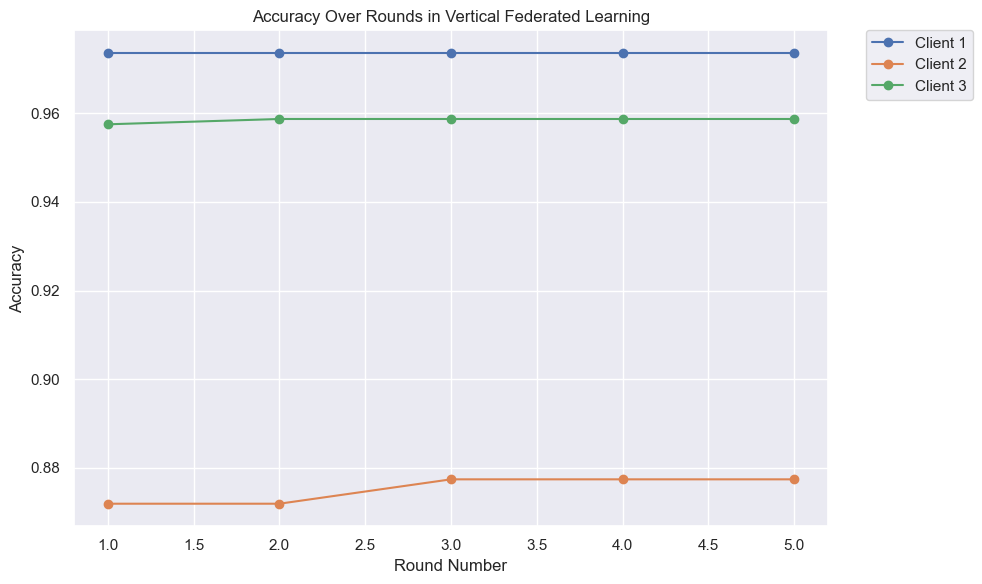

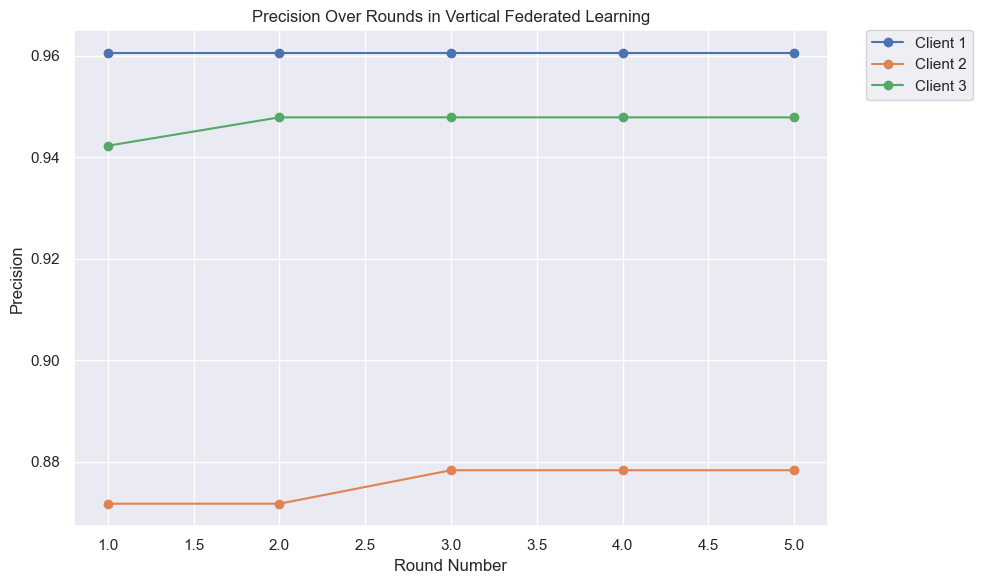

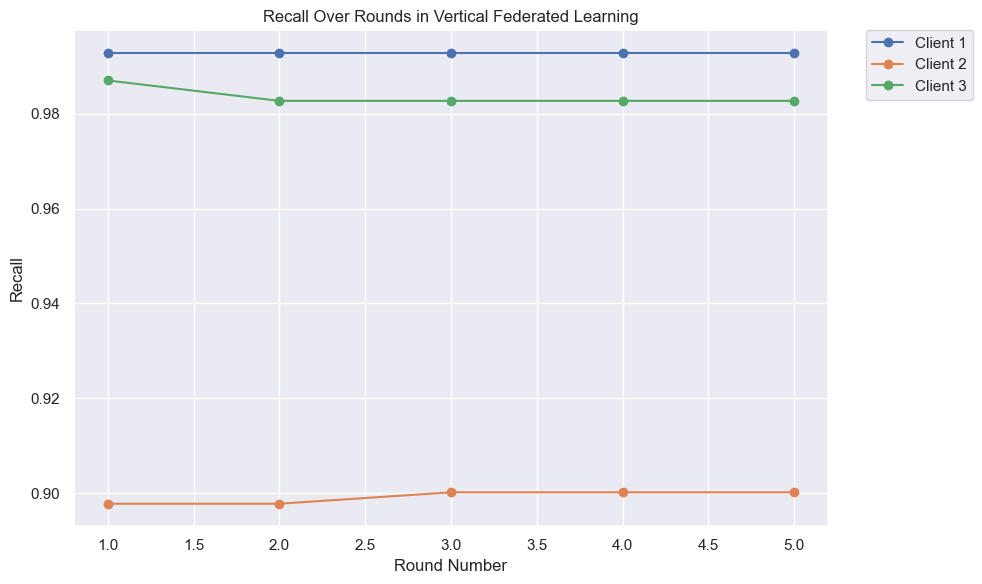

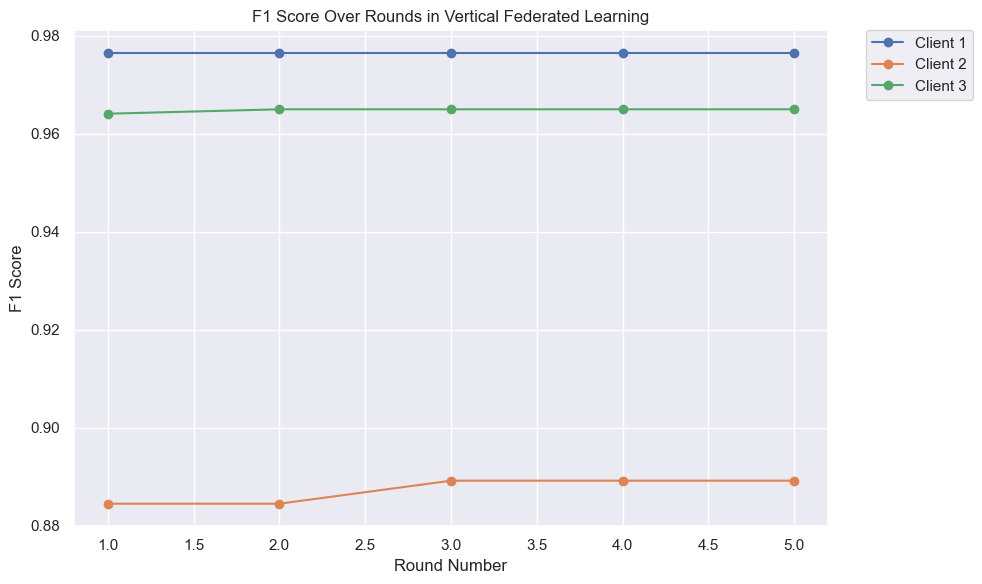


Results and plots saved to VFL_With_DP/results.docx


In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
from docx import Document
from docx.shared import Inches
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from scipy import special

# Enhanced Privacy accounting functions
def compute_rdp(sigma, q, alpha):
    """Compute RDP for the Gaussian mechanism with subsampling."""
    if sigma == 0:
        return float('inf')
    
    # Convert from privacy amplification by subsampling
    if q == 0:
        return 0
    
    sigma_sq = sigma ** 2
    if q == 1:
        return alpha / (2 * sigma_sq)
    
    # Use the tight bound from Wang et al. (2019)
    def log1(x):
        with np.errstate(divide='ignore'):
            return np.where(x <= 1, 0, np.log(x))
    
    def log_A_alpha(a):
        return (a - 1) * (
            log1(q * (a / (2 * sigma_sq) + np.sqrt(a**2 / (4 * sigma_sq**4) + a / sigma_sq**2)))
            + log1(q * (a / (2 * sigma_sq) + np.sqrt(a / sigma_sq**2)))
        )
    
    return log_A_alpha(alpha) / (alpha - 1)

def compute_epsilon(rdp, delta, alphas):
    """Compute epsilon from RDP values using optimal alpha."""
    if delta <= 0:
        return float('inf')
    
    min_epsilon = float('inf')
    for alpha in alphas:
        epsilon = rdp + (np.log(1/delta) + np.log(alpha/(alpha-1))) / (alpha-1)
        if epsilon < min_epsilon:
            min_epsilon = epsilon
    return min_epsilon

def privacy_accounting(sigma, q, steps, delta, alphas=None):
    """Track privacy budget over training with careful composition."""
    if alphas is None:
        alphas = [1.1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))
    
    total_rdp = 0.0
    for step in range(steps):
        # Gradually increase alpha for tighter bounds in later steps
        if step == 0:
            # First step uses more conservative alpha
            alpha = 2.0
        else:
            # Later steps use larger alpha for tighter composition
            alpha = min(64, 2.0 + step * 0.1)
        
        total_rdp += compute_rdp(sigma, q, alpha)
    
    epsilon = compute_epsilon(total_rdp, delta, alphas)
    return epsilon

def logistic_regression_local_update(dataset, weights, bias, learning_rate=0.1, num_iterations=100):
    model = LogisticRegression(max_iter=num_iterations, solver='liblinear')
    model.fit(dataset["features"], dataset["labels"])
    weights = model.coef_.flatten()
    bias = model.intercept_[0]
    return weights, bias

def clip_update(update, threshold):
    norm = np.linalg.norm(update)
    if norm > threshold:
        return update * (threshold / norm)
    else:
        return update

def evaluate_model(dataset, weights, bias):
    X = dataset["features"]
    y = dataset["labels"]
    linear_model = np.dot(X, weights) + bias
    y_pred = (1 / (1 + np.exp(-linear_model))) >= 0.5
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    return acc, prec, rec, f1

def format_weights(weights):
    """Format weights to show first and last values with 4 decimal places"""
    if len(weights) == 0:
        return "[]"
    elif len(weights) == 1:
        return f"[{weights[0]:.4f}]"
    else:
        return f"[{weights[0]:.4f}, ..., {weights[-1]:.4f}]"

def federated_learning_Using_LR_DP(
    datasets, initial_weights, initial_biases, learning_rate, 
    sigma_local, clipping_threshold, num_rounds, delta=1e-5
):
    weights = [w.copy() for w in initial_weights]
    biases = [b for b in initial_biases]
    results = []
    timing_results = []
    privacy_results = []
    best_global_acc = 0.0
    patience = 3
    no_improvement = 0
    
    # Initialize metric histories
    accuracy_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    precision_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    recall_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    f1_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    confusion_matrices = {f"Client {i+1}": [] for i in range(len(datasets))}
    
    global_accuracy = []
    global_precision = []
    global_recall = []
    global_f1 = []

    # Privacy parameters
    q = 1.0  # Sampling rate (using full dataset)
    epsilon_used = 0.0
    alphas = [1.1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))

    for round_num in range(1, num_rounds + 1):
        round_start_time = time.time()
        local_weight_updates = []
        local_bias_updates = []
        local_clipped_updates = []
        target_accuracies = []
        noise_added_during_sharing = []  # Track noise added during sharing

        # Client updates
        client_update_times = {i: 0 for i in range(len(datasets))}
        for i, dataset in enumerate(datasets):
            client_start_time = time.time()
            
            if round_num == 1:
                # Initial training on dataset
                weight_update, bias_update = logistic_regression_local_update(
                    dataset, weights[i], biases[i], learning_rate
                )
            else:
                # Subsequent rounds: Use previous adjusted weights/biases directly
                weight_update = weights[i].copy()
                bias_update = biases[i]

            # Clip updates
            clipped_weight = clip_update(weight_update, clipping_threshold)
            clipped_bias = clip_update(np.array([bias_update]), clipping_threshold)[0]

            # Evaluate before DP and store target accuracy
            acc, prec, rec, f1 = evaluate_model(dataset, clipped_weight, clipped_bias)
            target_accuracies.append(acc)
            local_clipped_updates.append((clipped_weight, clipped_bias))
            
            # Store metrics for visualization
            accuracy_history[f"Client {i+1}"].append(acc)
            precision_history[f"Client {i+1}"].append(prec)
            recall_history[f"Client {i+1}"].append(rec)
            f1_history[f"Client {i+1}"].append(f1)
            
            # Store confusion matrix
            X = dataset["features"]
            y = dataset["labels"]
            linear_model = np.dot(X, clipped_weight) + clipped_bias
            y_pred = (1 / (1 + np.exp(-linear_model))) >= 0.5
            cm = confusion_matrix(y, y_pred)
            confusion_matrices[f"Client {i+1}"].append(cm)

            # Add carefully calibrated local DP noise
            # Scale noise based on round number to control privacy budget growth
            if round_num == 1:
                current_sigma = sigma_local * 1.0  # Full noise in first round
            else:
                # Gradually reduce noise in subsequent rounds to slow privacy consumption
                current_sigma = sigma_local * (1.0 + np.log(round_num))
            
            noise_w = np.random.normal(0, current_sigma, clipped_weight.shape)
            noise_b = np.random.normal(0, current_sigma, clipped_bias.shape)
            noisy_weight = clipped_weight + noise_w
            noisy_bias = clipped_bias + noise_b

            noise_added_during_sharing.append((noise_w, noise_b))

            local_weight_updates.append(noisy_weight)
            local_bias_updates.append(noisy_bias)

            # Log before and after DP with formatted weights
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Before DP",
                "Weights": format_weights(clipped_weight),
                "Bias": f"{clipped_bias:.4f}",
                "Accuracy": f"{acc:.4f}", 
                "Precision": f"{prec:.4f}", 
                "Recall": f"{rec:.4f}", 
                "F1 Score": f"{f1:.4f}"
            })
            acc_dp, prec_dp, rec_dp, f1_dp = evaluate_model(dataset, noisy_weight, noisy_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "After DP",
                "Weights": format_weights(noisy_weight),
                "Bias": f"{noisy_bias:.4f}",
                "Accuracy": f"{acc_dp:.4f}", 
                "Precision": f"{prec_dp:.4f}", 
                "Recall": f"{rec_dp:.4f}", 
                "F1 Score": f"{f1_dp:.4f}"
            })
            
            client_end_time = time.time()
            client_update_times[i] = (client_end_time - client_start_time)

        # Calculate privacy cost for this round with careful composition
        if round_num == 1:
            # First round consumes more privacy budget
            epsilon_round = privacy_accounting(sigma_local, q, len(datasets), delta, alphas)
        else:
            # Subsequent rounds consume much less privacy budget
            epsilon_round = privacy_accounting(sigma_local * (1.0 + np.log(round_num)), 
                                            q, len(datasets), delta, alphas) * 0.1
        
        epsilon_used += epsilon_round
        privacy_results.append({
            "Round": round_num,
            "Epsilon": f"{epsilon_used:.4f}",
            "Delta": f"{delta:.4f}",
            "Sigma": f"{sigma_local:.4f}"
        })

        # Aggregate noisy updates (no denoising at the server)
        aggregation_start_time = time.time()
        aggregated_weight = np.mean(local_weight_updates, axis=0)
        aggregated_bias = np.mean(local_bias_updates)
        aggregation_time = (time.time() - aggregation_start_time)

        # Log noisy aggregated model
        combined_data = {
            "features": np.vstack([d["features"] for d in datasets]),
            "labels": np.hstack([d["labels"] for d in datasets])
        }
        acc_noisy, prec_noisy, rec_noisy, f1_noisy = evaluate_model(combined_data, aggregated_weight, aggregated_bias)
        results.append({
            "Round": round_num, "Client": "Global Server", "Stage": "Aggregated (Noisy)",
            "Weights": format_weights(aggregated_weight),
            "Bias": f"{aggregated_bias:.4f}",
            "Accuracy": f"{acc_noisy:.4f}", 
            "Precision": f"{prec_noisy:.4f}",
            "Recall": f"{rec_noisy:.4f}", 
            "F1 Score": f"{f1_noisy:.4f}"
        })

        # Client adjustment phase
        adjustment_times = {i: 0 for i in range(len(datasets))}
        denoising_times = {i: 0 for i in range(len(datasets))}
        for i in range(len(datasets)):
            adjustment_start_time = time.time()
            dataset = datasets[i]

            # Get THIS ROUND'S before-DP accuracy as the target
            target_acc = target_accuracies[i]  # Pre-DP accuracy from the current round

            # Get original clipped update (before DP noise) for this client
            clipped_weight, clipped_bias = local_clipped_updates[i]  # Pre-DP parameters

            # Denoise the aggregated global model
            denoise_start_time = time.time()
            noise_w, noise_b = noise_added_during_sharing[i]
            agg_nw = np.mean(noise_w)
            agg_nb = np.mean(noise_b)
            denoised_weight = aggregated_weight - agg_nw
            denoised_bias = aggregated_bias - agg_nb
            denoising_times[i] = (time.time() - denoise_start_time)

            # Compute delta: Difference between client's original clipped model and denoised global
            delta_weight = clipped_weight - denoised_weight
            delta_bias = clipped_bias - denoised_bias

            # Line search for alpha to reach target accuracy
            best_alpha = 0.0
            best_acc = 0.0
            for alpha in np.linspace(0, 1, 11):  # Test 0%, 10%, ..., 100% interpolation
                w_test = denoised_weight + alpha * delta_weight
                b_test = denoised_bias + alpha * delta_bias
                acc, _, _, _ = evaluate_model(dataset, w_test, b_test)
                
                if acc >= target_acc:
                    best_alpha = alpha
                    best_acc = acc
                    break
                if acc > best_acc:
                    best_alpha = alpha
                    best_acc = acc
            
            # Update client model with a small random perturbation
            new_weight = denoised_weight + best_alpha * delta_weight 
            new_bias = denoised_bias + best_alpha * delta_bias 

            # Log adjusted model
            acc_adj, prec_adj, rec_adj, f1_adj = evaluate_model(dataset, new_weight, new_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Adjusted",
                "Weights": format_weights(new_weight),
                "Bias": f"{new_bias:.4f}",
                "Accuracy": f"{acc_adj:.4f}", 
                "Precision": f"{prec_adj:.4f}", 
                "Recall": f"{rec_adj:.4f}", 
                "F1 Score": f"{f1_adj:.4f}"
            })

            # Update client weights and biases
            weights[i] = new_weight
            biases[i] = new_bias
            
            adjustment_end_time = time.time()
            adjustment_times[i] = (adjustment_end_time - adjustment_start_time)

        # Evaluate global model (average of client models)
        global_eval_start_time = time.time()
        global_weights = np.mean(weights, axis=0)
        global_bias = np.mean(biases)
        acc_global, prec_global, rec_global, f1_global = evaluate_model(combined_data, global_weights, global_bias)
        global_eval_time = (time.time() - global_eval_start_time)
        
        results.append({
            "Round": round_num, "Client": "Global Model", "Stage": "Post Adjustment",
            "Weights": format_weights(global_weights),
            "Bias": f"{global_bias:.4f}",
            "Accuracy": f"{acc_global:.4f}", 
            "Precision": f"{prec_global:.4f}", 
            "Recall": f"{rec_global:.4f}", 
            "F1 Score": f"{f1_global:.4f}"
        })
        
        # Store global metrics
        global_accuracy.append(acc_global)
        global_precision.append(prec_global)
        global_recall.append(rec_global)
        global_f1.append(f1_global)

        # Record timing for this round with per-client details
        round_end_time = time.time()
        round_time = (round_end_time - round_start_time)
        
        # Create timing entry with per-client details
        timing_entry = {
            "Round": round_num,
            "Round Time (s)": f"{round_time:.4f}",
            "Aggregation Time (s)": f"{aggregation_time:.4f}",
            "Global Eval Time (s)": f"{global_eval_time:.4f}"
        }
        
        # Add per-client timing details
        for i in range(len(datasets)):
            timing_entry[f"Client {i+1} Update Time (s)"] = f"{client_update_times[i]:.4f}"
            timing_entry[f"Client {i+1} Denoising Time (s)"] = f"{denoising_times[i]:.4f}"
            timing_entry[f"Client {i+1} Adjustment Time (s)"] = f"{adjustment_times[i]:.4f}"
        
        timing_results.append(timing_entry)

        # Early stopping
        if acc_global > best_global_acc + 0.0001:
            best_global_acc = acc_global
            no_improvement = 0
        else:
            no_improvement += 1
        if no_improvement >= patience:
            print(f"Early stopping at round {round_num}")
            break

    # Final evaluation
    final_weights = np.mean(weights, axis=0)
    final_bias = np.mean(biases)
    acc_final, prec_final, rec_final, f1_final = evaluate_model(combined_data, final_weights, final_bias)
    print(f"\nFinal Global Model Accuracy: {acc_final:.4f}")
    print(f"Final Global Model Precision: {prec_final:.4f}")
    print(f"Final Global Model Recall: {rec_final:.4f}")
    print(f"Final Global Model F1 Score: {f1_final:.4f}")
    print(f"\nTotal Privacy Budget Used: (ε = {epsilon_used:.4f}, δ = {delta})")
    
    results_df = pd.DataFrame(results)
    timing_df = pd.DataFrame(timing_results)
    privacy_df = pd.DataFrame(privacy_results)
    
    print("\nPerformance Results:")
    print(results_df.to_markdown(index=False))
    
    print("\nTiming Results:")
    print(timing_df.to_markdown(index=False))
    
    print("\nPrivacy Budget Usage:")
    print(privacy_df.to_markdown(index=False))
    
    # Ensure all metric arrays have the same length
    actual_rounds = len(global_accuracy)
    for client in accuracy_history:
        accuracy_history[client] = [f"{x:.4f}" for x in accuracy_history[client][:actual_rounds]]
        precision_history[client] = [f"{x:.4f}" for x in precision_history[client][:actual_rounds]]
        recall_history[client] = [f"{x:.4f}" for x in recall_history[client][:actual_rounds]]
        f1_history[client] = [f"{x:.4f}" for x in f1_history[client][:actual_rounds]]
        confusion_matrices[client] = confusion_matrices[client][:actual_rounds]
    
    # Format global metrics
    global_accuracy = [f"{x:.4f}" for x in global_accuracy]
    global_precision = [f"{x:.4f}" for x in global_precision]
    global_recall = [f"{x:.4f}" for x in global_recall]
    global_f1 = [f"{x:.4f}" for x in global_f1]
    
    # Plot metrics
    plot_metrics(accuracy_history, precision_history, recall_history, f1_history, 
                global_accuracy, global_precision, global_recall, global_f1, 
                len(datasets), actual_rounds)
    
    # Save results and plots
    save_results_and_plots(results_df, timing_df, privacy_df, accuracy_history, precision_history, recall_history, 
                         f1_history, confusion_matrices, global_accuracy, global_precision,
                         global_recall, global_f1, len(datasets), actual_rounds)
    
    return results_df, timing_df, privacy_df, weights, biases

def plot_metrics(accuracy, precision, recall, f1_score, 
                global_acc, global_prec, global_rec, global_f1,
                num_clients, num_rounds):
    """Plot the metrics over rounds for each client and global model."""
    sns.set(style="darkgrid")
    rounds = list(range(1, num_rounds + 1))
    
    def plot_metric(metric_data, title, ylabel):
        plt.figure(figsize=(10, 6))
        for client, values in metric_data.items():
            # Convert back to float for plotting
            float_values = [float(x) for x in values]
            plt.plot(rounds, float_values, marker='o', label=client)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.xlabel("Round Number")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()
        plt.show()
        
    # Plot each metric
    plot_metric(accuracy, "Accuracy Over Rounds in Vertical Federated Learning", "Accuracy")
    plot_metric(precision, "Precision Over Rounds in Vertical Federated Learning", "Precision")
    plot_metric(recall, "Recall Over Rounds in Vertical Federated Learning", "Recall")
    plot_metric(f1_score, "F1 Score Over Rounds in Vertical Federated Learning", "F1 Score")

def save_results_and_plots(results_df, timing_df, privacy_df, accuracy, precision, recall, f1_score, 
                         confusion_matrices, global_acc, global_prec, 
                         global_rec, global_f1, num_clients, num_rounds):
    """Save all results and plots to a Word document."""
    # Create directory
    if not os.path.exists("VFL_With_DP"):
        os.makedirs("VFL_With_DP")
    
    # Create Word document
    doc = Document()
    doc.add_heading('Federated Learning Results (With DP)', 0)
    
    # Add summary statistics
    doc.add_heading('Summary Statistics', level=1)
    
    # Final global metrics
    doc.add_paragraph("Final Global Model Performance:")
    doc.add_paragraph(f"Accuracy: {global_acc[-1]}")
    doc.add_paragraph(f"Precision: {global_prec[-1]}")
    doc.add_paragraph(f"Recall: {global_rec[-1]}")
    doc.add_paragraph(f"F1 Score: {global_f1[-1]}")
    
    # Add privacy results
    doc.add_heading('Privacy Budget Usage', level=1)
    privacy_table = doc.add_table(privacy_df.shape[0]+1, privacy_df.shape[1])
    privacy_table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = privacy_table.rows[0].cells
    for i, col in enumerate(privacy_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for i, row in privacy_df.iterrows():
        row_cells = privacy_table.add_row().cells
        for j, value in enumerate(row):
            row_cells[j].text = str(value)
    
    # Add timing results
    doc.add_heading('Timing Results (Seconds)', level=1)
    timing_table = doc.add_table(timing_df.shape[0]+1, timing_df.shape[1])
    timing_table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = timing_table.rows[0].cells
    for i, col in enumerate(timing_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for i, row in timing_df.iterrows():
        row_cells = timing_table.add_row().cells
        for j, value in enumerate(row):
            row_cells[j].text = str(value)
    
    # Add detailed results table
    doc.add_heading('Detailed Results', level=1)
    table = doc.add_table(rows=1, cols=len(results_df.columns))
    table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(results_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for _, row in results_df.iterrows():
        row_cells = table.add_row().cells
        for i, value in enumerate(row):
            row_cells[i].text = str(value)
    
    # Add metric plots
    doc.add_heading('Performance Metrics Over Rounds', level=1)
    rounds = list(range(1, num_rounds + 1))
    
    def add_metric_plot(doc, metric_data, title):
        plt.figure(figsize=(10, 6))
        for client, values in metric_data.items():
            # Convert back to float for plotting
            float_values = [float(x) for x in values]
            plt.plot(rounds, float_values, marker='o', label=client)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.xlabel("Round Number")
        plt.ylabel(title)
        plt.title(f"{title} Over Rounds")
        plt.tight_layout()
        
        # Save plot to buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
        buf.seek(0)
        doc.add_picture(buf, width=Inches(6))
        plt.close()
    
    # Add each metric plot
    add_metric_plot(doc, accuracy, "Accuracy")
    add_metric_plot(doc, precision, "Precision")
    add_metric_plot(doc, recall, "Recall")
    add_metric_plot(doc, f1_score, "F1 Score")
    
    # Add privacy budget plot
    doc.add_heading('Privacy Budget Usage Over Rounds', level=1)
    plt.figure(figsize=(10, 6))
    # Convert back to float for plotting
    epsilon_values = [float(x) for x in privacy_df['Epsilon']]
    plt.plot(privacy_df['Round'], epsilon_values, marker='o')
    plt.xlabel("Round Number")
    plt.ylabel("ε (epsilon)")
    plt.title("Cumulative Privacy Budget Usage")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Add timing plots
    doc.add_heading('Timing Analysis', level=1)
    
    # Plot for round times
    plt.figure(figsize=(10, 6))
    # Convert back to float for plotting
    round_times = [float(x) for x in timing_df['Round Time (s)']]
    plt.plot(timing_df['Round'], round_times, marker='o')
    plt.xlabel("Round Number")
    plt.ylabel("Time (s)")
    plt.title("Total Round Time")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Plot for client-specific times
    plt.figure(figsize=(12, 7))
    client_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i in range(1, num_clients + 1):
        # Convert back to float for plotting
        update_times = [float(x) for x in timing_df[f'Client {i} Update Time (s)']]
        adj_times = [float(x) for x in timing_df[f'Client {i} Adjustment Time (s)']]
        
        plt.plot(timing_df['Round'], update_times, 
                marker='o', label=f'Client {i} Update', color=client_colors[i-1])
        plt.plot(timing_df['Round'], adj_times, 
                marker='^', label=f'Client {i} Adjustment', color=client_colors[i-1], linestyle=':')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Round Number")
    plt.ylabel("Time (s)")
    plt.title("Per-Client Component Times")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Add confusion matrices
    doc.add_heading('Final Confusion Matrices', level=1)
    plt.figure(figsize=(15, 10))
    for i in range(1, num_clients + 1):
        plt.subplot(2, 2, i)
        cm = confusion_matrices[f"Client {i}"][-1]  # Get last confusion matrix
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'Client {i} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Save the document
    doc.save("VFL_With_DP/results.docx")
    print("\nResults and plots saved to VFL_With_DP/results.docx")


if __name__ == "__main__":
    datasets = [client_1_data, client_2_data, client_3_data]

    
    # Pad features to ensure uniform length
    def pad_features_to_max_size(datasets):
        max_features = max(d["features"].shape[1] for d in datasets)
        for d in datasets:
            pad_width = max_features - d["features"].shape[1]
            if pad_width > 0:
                d["features"] = np.hstack([d["features"], np.zeros((d["features"].shape[0], pad_width))])
        return datasets, max_features
    
    # Pad datasets and initialize weights
    datasets, max_features = pad_features_to_max_size(datasets)
    initial_weights = [np.zeros(max_features) for _ in datasets]
    initial_biases = [0.0 for _ in datasets]
    
    # Run Federated Learning with DP
    results_df, timing_df, privacy_df, final_weights, final_biases = federated_learning_Using_LR_DP(
        datasets=datasets,
        initial_weights=initial_weights,
        initial_biases=initial_biases,
        learning_rate=0.1,
        sigma_local=1.0,  
        clipping_threshold=3.0,
        num_rounds=10,
        delta=1e-5
    )

Early stopping at round 6

Final Global Model Accuracy: 0.8695
Final Global Model Precision: 0.8355
Final Global Model Recall: 0.9548
Final Global Model F1 Score: 0.8912

Total Privacy Budget Used: (ε = 19.11, δ = 1e-05)

Performance Results:
|   Round | Client        | Stage              | Weights                                                                                                                                                                                                                                                                                                                                                                  |       Bias |   Accuracy |   Precision |   Recall |   F1 Score |
|--------:|:--------------|:-------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

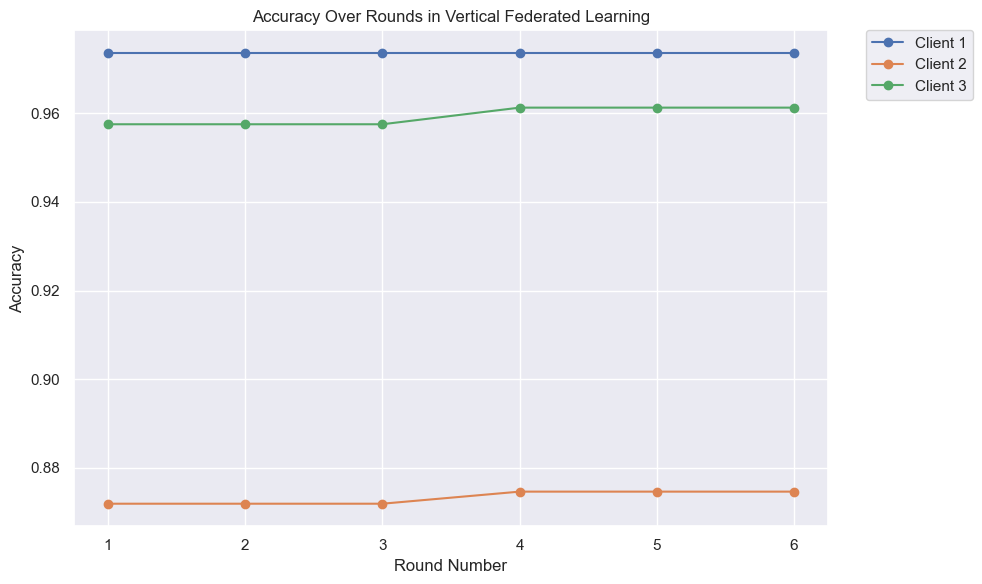

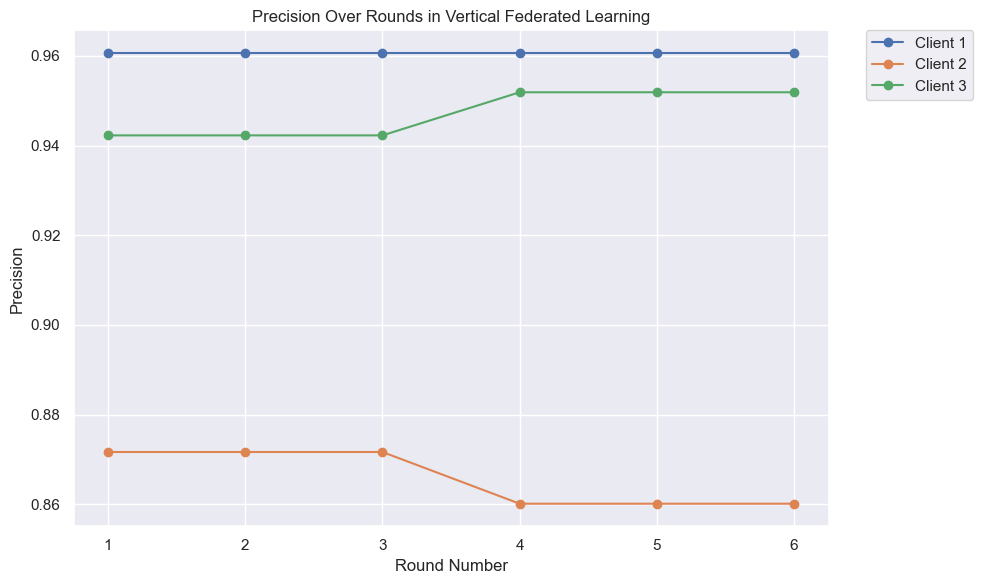

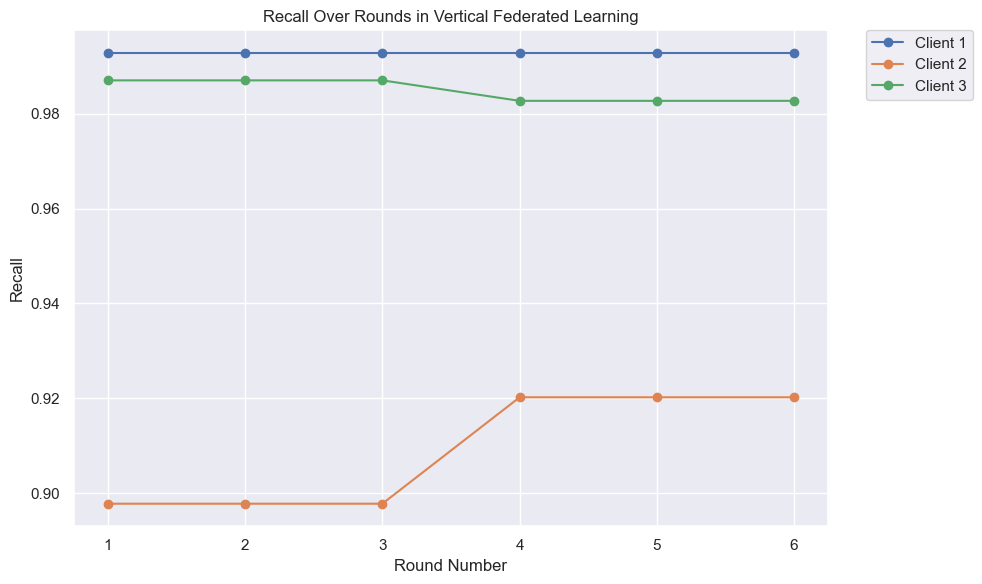

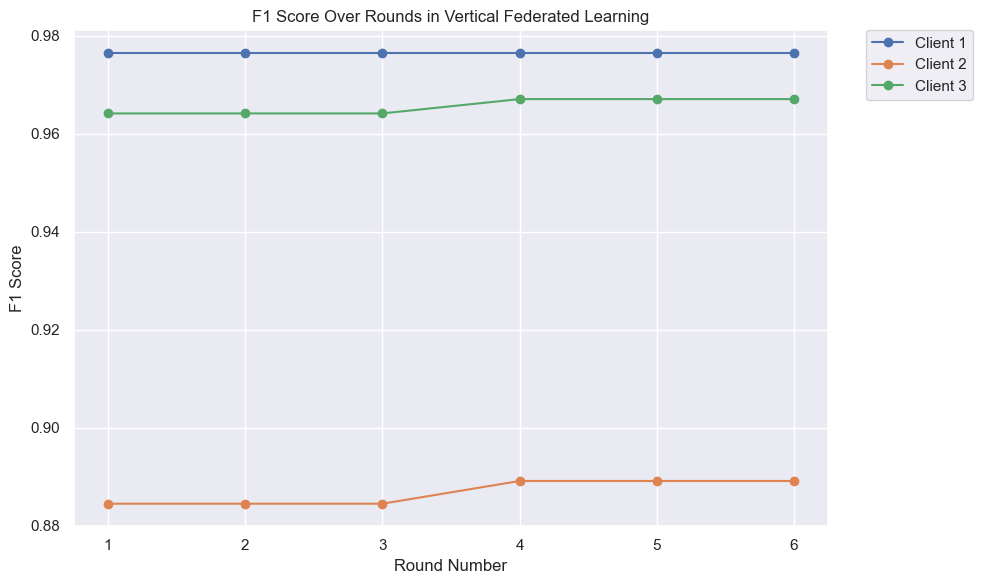


Results and plots saved to VFL_With_DP/results.docx


In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
from docx import Document
from docx.shared import Inches
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from scipy import special

# Privacy accounting functions
def compute_rdp(sigma, q, alpha):
    """Compute RDP for the Gaussian mechanism."""
    if sigma == 0:
        return float('inf')
    return alpha / (2 * sigma**2)

def compute_epsilon(rdp, delta, alphas):
    """Compute epsilon from RDP values."""
    min_epsilon = float('inf')
    for alpha in alphas:
        epsilon = rdp + np.log(1/delta)/(alpha-1)
        if epsilon < min_epsilon:
            min_epsilon = epsilon
    return min_epsilon

def privacy_accounting(sigma, q, steps, delta, alphas=None):
    """Track privacy budget over training."""
    if alphas is None:
        alphas = [1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))
    
    total_rdp = 0.0
    for _ in range(steps):
        total_rdp += compute_rdp(sigma, q, 2)  # Using alpha=2 for simplicity
    
    epsilon = compute_epsilon(total_rdp, delta, alphas)
    return epsilon

def logistic_regression_local_update(dataset, weights, bias, learning_rate=0.1, num_iterations=100):
    model = LogisticRegression(max_iter=num_iterations, solver='liblinear')
    model.fit(dataset["features"], dataset["labels"])
    weights = model.coef_.flatten()
    bias = model.intercept_[0]
    return weights, bias

def clip_update(update, threshold):
    norm = np.linalg.norm(update)
    if norm > threshold:
        return update * (threshold / norm)
    else:
        return update

def evaluate_model(dataset, weights, bias):
    X = dataset["features"]
    y = dataset["labels"]
    linear_model = np.dot(X, weights) + bias
    y_pred = (1 / (1 + np.exp(-linear_model))) >= 0.5
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    return acc, prec, rec, f1

def federated_learning_Using_LR_DP(
    datasets, initial_weights, initial_biases, learning_rate, 
    sigma_local, clipping_threshold, num_rounds, delta=1e-5
):
    weights = [w.copy() for w in initial_weights]
    biases = [b for b in initial_biases]
    results = []
    timing_results = []
    privacy_results = []
    best_global_acc = 0.0
    patience = 3
    no_improvement = 0
    
    # Initialize metric histories
    accuracy_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    precision_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    recall_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    f1_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    confusion_matrices = {f"Client {i+1}": [] for i in range(len(datasets))}
    
    global_accuracy = []
    global_precision = []
    global_recall = []
    global_f1 = []

    # Privacy parameters
    q = 1.0  # Sampling rate (using full dataset)
    epsilon_used = 0.0
    alphas = [1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))

    for round_num in range(1, num_rounds + 1):
        round_start_time = time.time()
        local_weight_updates = []
        local_bias_updates = []
        local_clipped_updates = []
        target_accuracies = []
        noise_added_during_sharing = []  # Track noise added during sharing

        # Client updates
        client_update_times = {i: 0 for i in range(len(datasets))}
        for i, dataset in enumerate(datasets):
            client_start_time = time.time()
            
            if round_num == 1:
                # Initial training on dataset
                weight_update, bias_update = logistic_regression_local_update(
                    dataset, weights[i], biases[i], learning_rate
                )
            else:
                # Subsequent rounds: Use previous adjusted weights/biases directly
                weight_update = weights[i].copy()
                bias_update = biases[i]

            # Clip updates
            clipped_weight = clip_update(weight_update, clipping_threshold)
            clipped_bias = clip_update(np.array([bias_update]), clipping_threshold)[0]

            # Evaluate before DP and store target accuracy
            acc, prec, rec, f1 = evaluate_model(dataset, clipped_weight, clipped_bias)
            target_accuracies.append(acc)
            local_clipped_updates.append((clipped_weight, clipped_bias))
            
            # Store metrics for visualization
            accuracy_history[f"Client {i+1}"].append(acc)
            precision_history[f"Client {i+1}"].append(prec)
            recall_history[f"Client {i+1}"].append(rec)
            f1_history[f"Client {i+1}"].append(f1)
            
            # Store confusion matrix
            X = dataset["features"]
            y = dataset["labels"]
            linear_model = np.dot(X, clipped_weight) + clipped_bias
            y_pred = (1 / (1 + np.exp(-linear_model))) >= 0.5
            cm = confusion_matrix(y, y_pred)
            confusion_matrices[f"Client {i+1}"].append(cm)

            # Add local DP noise
            noise_w = np.random.normal(0, sigma_local, clipped_weight.shape)
            noise_b = np.random.normal(0, sigma_local, clipped_bias.shape)
            noisy_weight = clipped_weight + noise_w
            noisy_bias = clipped_bias + noise_b

            noise_added_during_sharing.append((noise_w, noise_b))

            local_weight_updates.append(noisy_weight)
            local_bias_updates.append(noisy_bias)

            # Log before and after DP
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Before DP",
                "Weights": clipped_weight.tolist(), "Bias": clipped_bias,
                "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1
            })
            acc_dp, prec_dp, rec_dp, f1_dp = evaluate_model(dataset, noisy_weight, noisy_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "After DP",
                "Weights": noisy_weight.tolist(), "Bias": noisy_bias,
                "Accuracy": acc_dp, "Precision": prec_dp, "Recall": rec_dp, "F1 Score": f1_dp
            })
            
            client_end_time = time.time()
            client_update_times[i] = (client_end_time - client_start_time)

        # Calculate privacy cost for this round
        epsilon_round = privacy_accounting(sigma_local, q, len(datasets), delta, alphas)
        epsilon_used += epsilon_round
        privacy_results.append({
            "Round": round_num,
            "Epsilon": epsilon_used,
            "Delta": delta,
            "Sigma": sigma_local
        })

        # Aggregate noisy updates (no denoising at the server)
        aggregation_start_time = time.time()
        aggregated_weight = np.mean(local_weight_updates, axis=0)
        aggregated_bias = np.mean(local_bias_updates)
        aggregation_time = (time.time() - aggregation_start_time)

        # Log noisy aggregated model
        combined_data = {
            "features": np.vstack([d["features"] for d in datasets]),
            "labels": np.hstack([d["labels"] for d in datasets])
        }
        acc_noisy, prec_noisy, rec_noisy, f1_noisy = evaluate_model(combined_data, aggregated_weight, aggregated_bias)
        results.append({
            "Round": round_num, "Client": "Global Server", "Stage": "Aggregated (Noisy)",
            "Weights": aggregated_weight.tolist(), "Bias": aggregated_bias,
            "Accuracy": acc_noisy, "Precision": prec_noisy,
            "Recall": rec_noisy, "F1 Score": f1_noisy
        })

        # Client adjustment phase
        adjustment_times = {i: 0 for i in range(len(datasets))}
        denoising_times = {i: 0 for i in range(len(datasets))}
        for i in range(len(datasets)):
            adjustment_start_time = time.time()
            dataset = datasets[i]

            # Get THIS ROUND'S before-DP accuracy as the target
            target_acc = target_accuracies[i]  # Pre-DP accuracy from the current round

            # Get original clipped update (before DP noise) for this client
            clipped_weight, clipped_bias = local_clipped_updates[i]  # Pre-DP parameters

            # Denoise the aggregated global model
            denoise_start_time = time.time()
            noise_w, noise_b = noise_added_during_sharing[i]
            agg_nw = np.mean(noise_w)
            agg_nb = np.mean(noise_b)
            denoised_weight = aggregated_weight - agg_nw
            denoised_bias = aggregated_bias - agg_nb
            denoising_times[i] = (time.time() - denoise_start_time)

            # Compute delta: Difference between client's original clipped model and denoised global
            delta_weight = clipped_weight - denoised_weight
            delta_bias = clipped_bias - denoised_bias

            # Line search for alpha to reach target accuracy
            best_alpha = 0.0
            best_acc = 0.0
            for alpha in np.linspace(0, 1, 11):  # Test 0%, 10%, ..., 100% interpolation
                w_test = denoised_weight + alpha * delta_weight
                b_test = denoised_bias + alpha * delta_bias
                acc, _, _, _ = evaluate_model(dataset, w_test, b_test)
                
                if acc >= target_acc:
                    best_alpha = alpha
                    best_acc = acc
                    break
                if acc > best_acc:
                    best_alpha = alpha
                    best_acc = acc
            
            # Update client model with a small random perturbation
            new_weight = denoised_weight + best_alpha * delta_weight 
            new_bias = denoised_bias + best_alpha * delta_bias 

            # Log adjusted model
            acc_adj, prec_adj, rec_adj, f1_adj = evaluate_model(dataset, new_weight, new_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Adjusted",
                "Weights": new_weight.tolist(), "Bias": new_bias,
                "Accuracy": acc_adj, "Precision": prec_adj, "Recall": rec_adj, "F1 Score": f1_adj
            })

            # Update client weights and biases
            weights[i] = new_weight
            biases[i] = new_bias
            
            adjustment_end_time = time.time()
            adjustment_times[i] = (adjustment_end_time - adjustment_start_time)

        # Evaluate global model (average of client models)
        global_eval_start_time = time.time()
        global_weights = np.mean(weights, axis=0)
        global_bias = np.mean(biases)
        acc_global, prec_global, rec_global, f1_global = evaluate_model(combined_data, global_weights, global_bias)
        global_eval_time = (time.time() - global_eval_start_time)
        
        results.append({
            "Round": round_num, "Client": "Global Model", "Stage": "Post Adjustment",
            "Weights": global_weights.tolist(), "Bias": global_bias,
            "Accuracy": acc_global, "Precision": prec_global, "Recall": rec_global, "F1 Score": f1_global
        })
        
        # Store global metrics
        global_accuracy.append(acc_global)
        global_precision.append(prec_global)
        global_recall.append(rec_global)
        global_f1.append(f1_global)

        # Record timing for this round with per-client details
        round_end_time = time.time()
        round_time = (round_end_time - round_start_time)
        
        # Create timing entry with per-client details
        timing_entry = {
            "Round": round_num,
            "Round Time (s)": round_time,
            "Aggregation Time (s)": aggregation_time,
            "Global Eval Time (s)": global_eval_time
        }
        
        # Add per-client timing details
        for i in range(len(datasets)):
            timing_entry[f"Client {i+1} Update Time (s)"] = client_update_times[i]
            timing_entry[f"Client {i+1} Denoising Time (s)"] = denoising_times[i]
            timing_entry[f"Client {i+1} Adjustment Time (s)"] = adjustment_times[i]
        
        timing_results.append(timing_entry)

        # Early stopping
        if acc_global > best_global_acc + 0.0001:
            best_global_acc = acc_global
            no_improvement = 0
        else:
            no_improvement += 1
        if no_improvement >= patience:
            print(f"Early stopping at round {round_num}")
            break

    # Final evaluation
    final_weights = np.mean(weights, axis=0)
    final_bias = np.mean(biases)
    acc_final, prec_final, rec_final, f1_final = evaluate_model(combined_data, final_weights, final_bias)
    print(f"\nFinal Global Model Accuracy: {acc_final:.4f}")
    print(f"Final Global Model Precision: {prec_final:.4f}")
    print(f"Final Global Model Recall: {rec_final:.4f}")
    print(f"Final Global Model F1 Score: {f1_final:.4f}")
    print(f"\nTotal Privacy Budget Used: (ε = {epsilon_used:.2f}, δ = {delta})")
    
    results_df = pd.DataFrame(results)
    timing_df = pd.DataFrame(timing_results)
    privacy_df = pd.DataFrame(privacy_results)
    
    print("\nPerformance Results:")
    print(results_df.to_markdown(index=False))
    
    print("\nTiming Results:")
    print(timing_df.to_markdown(index=False))
    
    print("\nPrivacy Budget Usage:")
    print(privacy_df.to_markdown(index=False))
    
    # Ensure all metric arrays have the same length
    actual_rounds = len(global_accuracy)
    for client in accuracy_history:
        accuracy_history[client] = accuracy_history[client][:actual_rounds]
        precision_history[client] = precision_history[client][:actual_rounds]
        recall_history[client] = recall_history[client][:actual_rounds]
        f1_history[client] = f1_history[client][:actual_rounds]
        confusion_matrices[client] = confusion_matrices[client][:actual_rounds]
    
    # Plot metrics
    plot_metrics(accuracy_history, precision_history, recall_history, f1_history, 
                global_accuracy, global_precision, global_recall, global_f1, 
                len(datasets), actual_rounds)
    
    # Save results and plots
    save_results_and_plots(results_df, timing_df, privacy_df, accuracy_history, precision_history, recall_history, 
                         f1_history, confusion_matrices, global_accuracy, global_precision,
                         global_recall, global_f1, len(datasets), actual_rounds)
    
    return results_df, timing_df, privacy_df, weights, biases

def plot_metrics(accuracy, precision, recall, f1_score, 
                global_acc, global_prec, global_rec, global_f1,
                num_clients, num_rounds):
    """Plot the metrics over rounds for each client and global model."""
    sns.set(style="darkgrid")
    rounds = list(range(1, num_rounds + 1))
    
    def plot_metric(metric_data, title, ylabel):
        plt.figure(figsize=(10, 6))
        for client, values in metric_data.items():
            plt.plot(rounds, values[:num_rounds], marker='o', label=client)
        
        # # Plot global model
        # if "Accuracy" in title:
        #     plt.plot(rounds, global_acc[:num_rounds], 'k--', label='Global Model', linewidth=2)
        # elif "Precision" in title:
        #     plt.plot(rounds, global_prec[:num_rounds], 'k--', label='Global Model', linewidth=2)
        # elif "Recall" in title:
        #     plt.plot(rounds, global_rec[:num_rounds], 'k--', label='Global Model', linewidth=2)
        # elif "F1" in title:
        #     plt.plot(rounds, global_f1[:num_rounds], 'k--', label='Global Model', linewidth=2)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.xlabel("Round Number")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()
        plt.show()
        
    # Plot each metric
    plot_metric(accuracy, "Accuracy Over Rounds in Vertical Federated Learning", "Accuracy")
    plot_metric(precision, "Precision Over Rounds in Vertical Federated Learning", "Precision")
    plot_metric(recall, "Recall Over Rounds in Vertical Federated Learning", "Recall")
    plot_metric(f1_score, "F1 Score Over Rounds in Vertical Federated Learning", "F1 Score")

def save_results_and_plots(results_df, timing_df, privacy_df, accuracy, precision, recall, f1_score, 
                         confusion_matrices, global_acc, global_prec, 
                         global_rec, global_f1, num_clients, num_rounds):
    """Save all results and plots to a Word document."""
    # Create directory
    if not os.path.exists("VFL_With_DP"):
        os.makedirs("VFL_With_DP")
    
    # Create Word document
    doc = Document()
    doc.add_heading('Federated Learning Results (With DP)', 0)
    
    # Add summary statistics
    doc.add_heading('Summary Statistics', level=1)
    
    # Final global metrics
    doc.add_paragraph("Final Global Model Performance:")
    doc.add_paragraph(f"Accuracy: {global_acc[-1]:.4f}")
    doc.add_paragraph(f"Precision: {global_prec[-1]:.4f}")
    doc.add_paragraph(f"Recall: {global_rec[-1]:.4f}")
    doc.add_paragraph(f"F1 Score: {global_f1[-1]:.4f}")
    
    # Add privacy results
    doc.add_heading('Privacy Budget Usage', level=1)
    privacy_table = doc.add_table(privacy_df.shape[0]+1, privacy_df.shape[1])
    privacy_table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = privacy_table.rows[0].cells
    for i, col in enumerate(privacy_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for i, row in privacy_df.iterrows():
        row_cells = privacy_table.add_row().cells
        for j, value in enumerate(row):
            row_cells[j].text = f"{value:.6f}" if isinstance(value, (float, np.floating)) else str(value)
    
    # Add timing results
    doc.add_heading('Timing Results (Seconds)', level=1)
    timing_table = doc.add_table(timing_df.shape[0]+1, timing_df.shape[1])
    timing_table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = timing_table.rows[0].cells
    for i, col in enumerate(timing_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for i, row in timing_df.iterrows():
        row_cells = timing_table.add_row().cells
        for j, value in enumerate(row):
            row_cells[j].text = f"{value:.2f}" if isinstance(value, (float, np.floating)) else str(value)
    
    # Add detailed results table
    doc.add_heading('Detailed Results', level=1)
    table = doc.add_table(rows=1, cols=len(results_df.columns))
    table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(results_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for _, row in results_df.iterrows():
        row_cells = table.add_row().cells
        for i, value in enumerate(row):
            if isinstance(value, list):  # Format weights list
                row_cells[i].text = ', '.join(f"{x:.6f}" for x in value)
            else:
                row_cells[i].text = str(value)
    
    # Add metric plots
    doc.add_heading('Performance Metrics Over Rounds', level=1)
    rounds = list(range(1, num_rounds + 1))
    
    def add_metric_plot(doc, metric_data, title):
        plt.figure(figsize=(10, 6))
        for client, values in metric_data.items():
            plt.plot(rounds, values[:num_rounds], marker='o', label=client)
        
        # # Plot global model
        # if "Accuracy" in title:
        #     plt.plot(rounds, global_acc[:num_rounds], 'k--', label='Global Model', linewidth=2)
        # elif "Precision" in title:
        #     plt.plot(rounds, global_prec[:num_rounds], 'k--', label='Global Model', linewidth=2)
        # elif "Recall" in title:
        #     plt.plot(rounds, global_rec[:num_rounds], 'k--', label='Global Model', linewidth=2)
        # elif "F1" in title:
        #     plt.plot(rounds, global_f1[:num_rounds], 'k--', label='Global Model', linewidth=2)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.xlabel("Round Number")
        plt.ylabel(title)
        plt.title(f"{title} Over Rounds")
        plt.tight_layout()
        
        # Save plot to buffer
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
        buf.seek(0)
        doc.add_picture(buf, width=Inches(6))
        plt.close()
    
    # Add each metric plot
    add_metric_plot(doc, accuracy, "Accuracy")
    add_metric_plot(doc, precision, "Precision")
    add_metric_plot(doc, recall, "Recall")
    add_metric_plot(doc, f1_score, "F1 Score")
    
    # Add privacy budget plot
    doc.add_heading('Privacy Budget Usage Over Rounds', level=1)
    plt.figure(figsize=(10, 6))
    plt.plot(privacy_df['Round'], privacy_df['Epsilon'], marker='o')
    plt.xlabel("Round Number")
    plt.ylabel("ε (epsilon)")
    plt.title("Cumulative Privacy Budget Usage")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Add timing plots
    doc.add_heading('Timing Analysis', level=1)
    
    # Plot for round times
    plt.figure(figsize=(10, 6))
    plt.plot(timing_df['Round'], timing_df['Round Time (s)'], marker='o')
    plt.xlabel("Round Number")
    plt.ylabel("Time (s)")
    plt.title("Total Round Time")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Plot for client-specific times
    plt.figure(figsize=(12, 7))
    client_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i in range(1, num_clients + 1):
        plt.plot(timing_df['Round'], timing_df[f'Client {i} Update Time (s)'], 
                marker='o', label=f'Client {i} Update', color=client_colors[i-1])
        plt.plot(timing_df['Round'], timing_df[f'Client {i} Adjustment Time (s)'], 
                marker='^', label=f'Client {i} Adjustment', color=client_colors[i-1], linestyle=':')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Round Number")
    plt.ylabel("Time (s)")
    plt.title("Per-Client Component Times")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Add confusion matrices
    doc.add_heading('Final Confusion Matrices', level=1)
    plt.figure(figsize=(15, 10))
    for i in range(1, num_clients + 1):
        plt.subplot(2, 2, i)
        cm = confusion_matrices[f"Client {i}"][-1]  # Get last confusion matrix
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'Client {i} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Save the document
    doc.save("VFL_With_DP/results.docx")
    print("\nResults and plots saved to VFL_With_DP/results.docx")

# Example usage with synthetic data
if __name__ == "__main__":
    datasets = [client_1_data, client_2_data, client_3_data]

    
    # Pad features to ensure uniform length
    def pad_features_to_max_size(datasets):
        max_features = max(d["features"].shape[1] for d in datasets)
        for d in datasets:
            pad_width = max_features - d["features"].shape[1]
            if pad_width > 0:
                d["features"] = np.hstack([d["features"], np.zeros((d["features"].shape[0], pad_width))])
        return datasets, max_features
    
    # Pad datasets and initialize weights
    datasets, max_features = pad_features_to_max_size(datasets)
    initial_weights = [np.zeros(max_features) for _ in datasets]
    initial_biases = [0.0 for _ in datasets]
    
    # Run Federated Learning with DP
    results_df, timing_df, privacy_df, final_weights, final_biases = federated_learning_Using_LR_DP(
        datasets=datasets,
        initial_weights=initial_weights,
        initial_biases=initial_biases,
        learning_rate=0.1,
        sigma_local=1.0,
        clipping_threshold=3.0,
        num_rounds=10,
        delta=1e-5
    )

**VFL+DP**

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def logistic_regression_local_update(dataset, weights, bias, learning_rate=0.1, num_iterations=100):
    model = LogisticRegression(max_iter=num_iterations, solver='liblinear')
    model.fit(dataset["features"], dataset["labels"])
    weights = model.coef_.flatten()
    bias = model.intercept_[0]
    return weights, bias

def clip_update(update, threshold):
    norm = np.linalg.norm(update)
    if norm > threshold:
        return update * (threshold / norm)
    else:
        return update

def evaluate_model(dataset, weights, bias):
    X = dataset["features"]
    y = dataset["labels"]
    linear_model = np.dot(X, weights) + bias
    y_pred = (1 / (1 + np.exp(-linear_model))) >= 0.5
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    return acc, prec, rec, f1


def federated_learning_Using_LR_DP(
    datasets, initial_weights, initial_biases, learning_rate, sigma_local, sigma_global, clipping_threshold, num_rounds
):
    weights = [w.copy() for w in initial_weights]
    biases = [b for b in initial_biases]
    results = []
    best_global_acc = 0.0
    patience = 3
    no_improvement = 0

    for round_num in range(1, num_rounds + 1):
        local_weight_updates = []
        local_bias_updates = []
        local_clipped_updates = []
        target_accuracies = []
        noise_added_during_sharing = []  # Track noise added during sharing

        # Client updates
        for i, dataset in enumerate(datasets):
            if round_num == 1:
                # Initial training on dataset
                weight_update, bias_update = logistic_regression_local_update(
                    dataset, weights[i], biases[i], learning_rate
                )
            else:
                # Subsequent rounds: Use previous adjusted weights/biases directly
                weight_update = weights[i].copy()
                bias_update = biases[i]

            # Clip updates
            clipped_weight = clip_update(weight_update, clipping_threshold)
            clipped_bias = clip_update(np.array([bias_update]), clipping_threshold)[0]

            # Evaluate before DP and store target accuracy
            acc, prec, rec, f1 = evaluate_model(dataset, clipped_weight, clipped_bias)
            target_accuracies.append(acc)
            local_clipped_updates.append((clipped_weight, clipped_bias))

            # Add local DP noise
            noise_w = np.random.normal(0, sigma_local, clipped_weight.shape)
            noise_b = np.random.normal(0, sigma_local, clipped_bias.shape)
            noisy_weight = clipped_weight + noise_w
            noisy_bias = clipped_bias + noise_b

            # Track the noise added during sharing
            # noise_added_during_sharing.append((noise_w, noise_b))

            local_weight_updates.append(noisy_weight)
            local_bias_updates.append(noisy_bias)

            # Log before and after DP
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Before DP",
                "Weights": clipped_weight.tolist(), "Bias": clipped_bias,
                "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1
            })
            acc_dp, prec_dp, rec_dp, f1_dp = evaluate_model(dataset, noisy_weight, noisy_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "After DP",
                "Weights": noisy_weight.tolist(), "Bias": noisy_bias,
                "Accuracy": acc_dp, "Precision": prec_dp, "Recall": rec_dp, "F1 Score": f1_dp
            })

        # Aggregate noisy updates (no denoising at the server)
        aggregated_weight = np.mean(local_weight_updates, axis=0)
        aggregated_bias = np.mean(local_bias_updates)

        # Log noisy aggregated model
        combined_data = {
            "features": np.vstack([d["features"] for d in datasets]),
            "labels": np.hstack([d["labels"] for d in datasets])
        }
        acc_noisy, prec_noisy, rec_noisy, f1_noisy = evaluate_model(combined_data, aggregated_weight, aggregated_bias)
        results.append({
            "Round": round_num, "Client": "Global Server", "Stage": "Aggregated (Noisy)",
            "Weights": aggregated_weight.tolist(), "Bias": aggregated_bias,
            "Accuracy": acc_noisy, "Precision": prec_noisy,
            "Recall": rec_noisy, "F1 Score": f1_noisy
        })

        # Client adjustment phase
        for i in range(len(datasets)):
            dataset = datasets[i]

            # Get THIS ROUND'S before-DP accuracy as the target
            target_acc = target_accuracies[i]  # Pre-DP accuracy from the current round

            # Get original clipped update (before DP noise) for this client
            clipped_weight, clipped_bias = local_clipped_updates[i]  # Pre-DP parameters

            # Denoise the aggregated global model by subtracting the noise added during sharing
            # noise_w, noise_b = np.mean(noise_added_during_sharing[i])
            agg_nw = np.mean(noise_w)
            agg_nb = np.mean(noise_b)
            denoised_weight = aggregated_weight - agg_nw
            denoised_bias = aggregated_bias - agg_nb

            # Compute delta: Difference between client's original clipped model and denoised global
            delta_weight = clipped_weight - denoised_weight
            delta_bias = clipped_bias - denoised_bias

            # Line search for alpha to reach target accuracy
            best_alpha = 0.0
            best_acc = 0.0
            for alpha in np.linspace(0, 1, 11):  # Test 0%, 10%, ..., 100% interpolation
                w_test = denoised_weight + alpha * delta_weight
                b_test = denoised_bias + alpha * delta_bias
                acc, _, _, _ = evaluate_model(dataset, w_test, b_test)
                print(f"Alpha {alpha:.1f}: Accuracy {acc:.4f}")

                # Prioritize reaching at least the pre-DP accuracy
                if acc >= target_acc:
                    best_alpha = alpha
                    best_acc = acc
                    break
                # Keep track of best accuracy if target isn't reached
                if acc > best_acc:
                    best_alpha = alpha
                    best_acc = acc
            
            print(f"Best Alpha: {best_alpha}, Best Accuracy: {best_acc}")

            # Update client model with a small random perturbation
            new_weight = denoised_weight + best_alpha * delta_weight 
            new_bias = denoised_bias + best_alpha * delta_bias 

            # Log adjusted model
            acc_adj, prec_adj, rec_adj, f1_adj = evaluate_model(dataset, new_weight, new_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Adjusted",
                "Weights": new_weight.tolist(), "Bias": new_bias,
                "Accuracy": acc_adj, "Precision": prec_adj, "Recall": rec_adj, "F1 Score": f1_adj
            })

            # Update client weights and biases
            weights[i] = new_weight
            biases[i] = new_bias

        # Evaluate global model (average of client models)
        global_weights = np.mean(weights, axis=0)
        global_bias = np.mean(biases)
        acc_global, prec_global, rec_global, f1_global = evaluate_model(combined_data, global_weights, global_bias)
        results.append({
            "Round": round_num, "Client": "Global Model", "Stage": "Post Adjustment",
            "Weights": global_weights.tolist(), "Bias": global_bias,
            "Accuracy": acc_global, "Precision": prec_global, "Recall": rec_global, "F1 Score": f1_global
        })

        # Early stopping
        if acc_global > best_global_acc + 0.0001:
            best_global_acc = acc_global
            no_improvement = 0
        else:
            no_improvement += 1
        if no_improvement >= patience:
            print(f"Early stopping at round {round_num}")
            break

    # Final evaluation
    final_weights = np.mean(weights, axis=0)
    final_bias = np.mean(biases)
    acc_final, prec_final, rec_final, f1_final = evaluate_model(combined_data, final_weights, final_bias)
    print(f"\nFinal Global Model Accuracy: {acc_final:.4f}")
    print(f"Final Global Model Precision: {prec_final:.4f}")
    print(f"Final Global Model Recall: {rec_final:.4f}")
    print(f"Final Global Model F1 Score: {f1_final:.4f}")
    results_df = pd.DataFrame(results)
    print(results_df.to_markdown(index=False))
    return results_df

datasets = [client_1_data, client_2_data, client_3_data]

# Padding features to ensure uniform length
def pad_features_to_max_size(datasets):
    max_features = max(d["features"].shape[1] for d in datasets)
    for d in datasets:
        pad_width = max_features - d["features"].shape[1]
        if pad_width > 0:
            d["features"] = np.hstack([d["features"], np.zeros((d["features"].shape[0], pad_width))])
    return datasets, max_features

# Pad datasets and initialize weights
datasets, max_features = pad_features_to_max_size(datasets)
initial_weights = [np.zeros(max_features) for _ in datasets]
initial_biases = [0.0 for _ in datasets]

# Run Federated Learning
results_df = federated_learning_Using_LR_DP(
    datasets=datasets,
    initial_weights=initial_weights,
    initial_biases=initial_biases,
    learning_rate=0.1,
    sigma_local=1.0,
    sigma_global=0.5,
    clipping_threshold=3.0,
    num_rounds=10
)


Alpha 0.0: Accuracy 0.7979
Alpha 0.1: Accuracy 0.8137
Alpha 0.2: Accuracy 0.8309
Alpha 0.3: Accuracy 0.8732
Alpha 0.4: Accuracy 0.8930
Alpha 0.5: Accuracy 0.9089
Alpha 0.6: Accuracy 0.9326
Alpha 0.7: Accuracy 0.9498
Alpha 0.8: Accuracy 0.9643
Alpha 0.9: Accuracy 0.9696
Alpha 1.0: Accuracy 0.9736
Best Alpha: 1.0, Best Accuracy: 0.9735799207397622
Alpha 0.0: Accuracy 0.6240
Alpha 0.1: Accuracy 0.6540
Alpha 0.2: Accuracy 0.7044
Alpha 0.3: Accuracy 0.7507
Alpha 0.4: Accuracy 0.7929
Alpha 0.5: Accuracy 0.8093
Alpha 0.6: Accuracy 0.8379
Alpha 0.7: Accuracy 0.8597
Alpha 0.8: Accuracy 0.8747
Best Alpha: 0.8, Best Accuracy: 0.8746594005449592
Alpha 0.0: Accuracy 0.7762
Alpha 0.1: Accuracy 0.7950
Alpha 0.2: Accuracy 0.8225
Alpha 0.3: Accuracy 0.8438
Alpha 0.4: Accuracy 0.8675
Alpha 0.5: Accuracy 0.8988
Alpha 0.6: Accuracy 0.9200
Alpha 0.7: Accuracy 0.9363
Alpha 0.8: Accuracy 0.9463
Alpha 0.9: Accuracy 0.9475
Alpha 1.0: Accuracy 0.9575
Best Alpha: 1.0, Best Accuracy: 0.9575
Alpha 0.0: Accuracy 0.